In [1]:
import os
import numpy as np
import rasterio
import torch
from torch.utils.data import Dataset

class FTWDataset(Dataset):

    def __init__(self, ids):

        self.ids = ids

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        chip = self.ids[idx]

        img_a = rasterio.open(
            f"window_a/{chip}.tif"
        ).read()

        img_b = rasterio.open(
            f"window_b/{chip}.tif"
        ).read()

        x = np.concatenate(
            [img_a, img_b],
            axis=0
        )

        x = x.astype(np.float32)

        x = (x - x.min()) / (
            x.max() - x.min() + 1e-8
        )

        mask = rasterio.open(
            f"semantic_3class/{chip}.tif"
        ).read(1)

        # Convert classes
        # 1->0 Field
        # 2->1 Boundary
        # 3->2 Background

        mask = mask - 1

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.long)
        )

In [2]:
import os

wa = set(f.replace(".tif","") for f in os.listdir("window_a"))
wb = set(f.replace(".tif","") for f in os.listdir("window_b"))
ms = set(f.replace(".tif","") for f in os.listdir("semantic_3class"))

common = sorted(list(wa & wb & ms))

print("Samples:", len(common))

Samples: 291


In [3]:
from sklearn.model_selection import train_test_split

train_ids, val_ids = train_test_split(
    common,
    test_size=0.2,
    random_state=42
)

print(len(train_ids))
print(len(val_ids))

232
59


In [4]:
from torch.utils.data import DataLoader

train_ds = FTWDataset(train_ids)
val_ds = FTWDataset(val_ids)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False
)

In [5]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

torch.Size([8, 8, 256, 256])
torch.Size([8, 256, 256])


In [6]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)
print(torch.unique(y))

torch.Size([8, 8, 256, 256])
torch.Size([8, 256, 256])
tensor([0, 1, 2])


In [7]:
import segmentation_models_pytorch as smp
import torch

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=8,
    classes=3
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

print("Device:", device)

Device: cuda


In [8]:
import torch.nn as nn

weights = torch.tensor(
    [5.0, 10.0, 0.1],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [10]:
def train_epoch():

    model.train()

    running_loss = 0

    for x,y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(
            pred,
            y
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(train_loader)

In [11]:
def val_epoch():

    model.eval()

    running_loss = 0

    with torch.no_grad():

        for x,y in val_loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            loss = criterion(
                pred,
                y
            )

            running_loss += loss.item()

    return running_loss / len(val_loader)

In [12]:
EPOCHS = 10

In [13]:
best_loss = 999

for epoch in range(EPOCHS):

    train_loss = train_epoch()

    val_loss = val_epoch()

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train: {train_loss:.4f}"
    )

    print(
        f"Val: {val_loss:.4f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_deeplabv3_ftw.pth"
        )

        print("Model Saved")

Epoch 1/10
Train: 1.0075
Val: 1.0471
Model Saved
Epoch 2/10
Train: 0.7689
Val: 0.7238
Model Saved
Epoch 3/10
Train: 0.6309
Val: 0.6835
Model Saved
Epoch 4/10
Train: 0.5547
Val: 0.6297
Model Saved
Epoch 5/10
Train: 0.5068
Val: 0.5290
Model Saved
Epoch 6/10
Train: 0.4744
Val: 0.5263
Model Saved
Epoch 7/10
Train: 0.4522
Val: 0.4937
Model Saved
Epoch 8/10
Train: 0.4326
Val: 0.5008
Epoch 9/10
Train: 0.4223
Val: 0.4967
Epoch 10/10
Train: 0.4087
Val: 0.4814
Model Saved


C:\Users\hp\AppData\Local\Temp\ipykernel_26236\3994107642.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


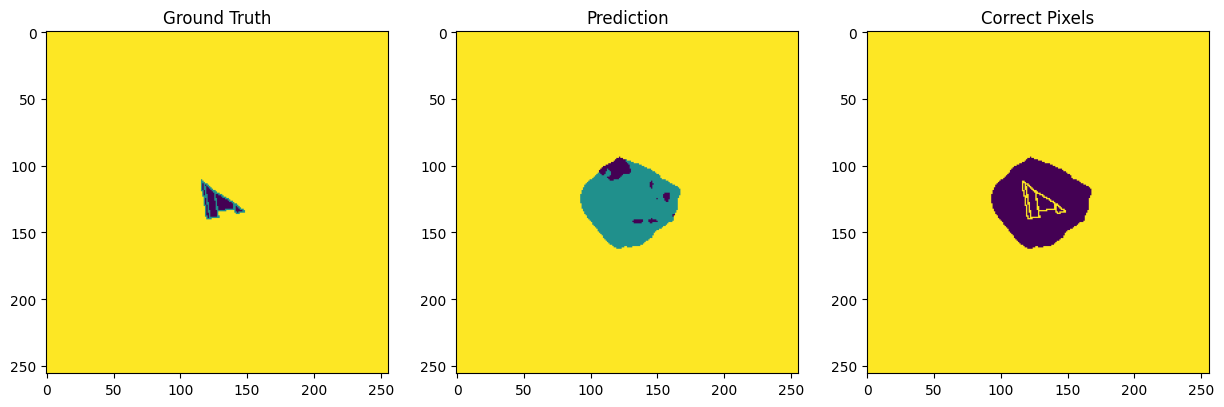

In [14]:
import matplotlib.pyplot as plt
import torch
import numpy as np

model.load_state_dict(
    torch.load(
        "best_deeplabv3_ftw.pth",
        map_location=device
    )
)

model.eval()

x,y = val_ds[0]

with torch.no_grad():

    pred = model(
        x.unsqueeze(0).to(device)
    )

pred = pred.argmax(1).squeeze().cpu().numpy()

gt = y.numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gt)
plt.title("Ground Truth")

plt.subplot(1,3,2)
plt.imshow(pred)
plt.title("Prediction")

plt.subplot(1,3,3)
plt.imshow(gt==pred)
plt.title("Correct Pixels")

plt.show()

In [15]:
import numpy as np

def iou_score(pred, gt, cls):

    pred_cls = (pred == cls)
    gt_cls = (gt == cls)

    inter = np.logical_and(
        pred_cls,
        gt_cls
    ).sum()

    union = np.logical_or(
        pred_cls,
        gt_cls
    ).sum()

    if union == 0:
        return np.nan

    return inter / union

In [16]:
ious = []

for i in range(len(val_ds)):

    x,y = val_ds[i]

    with torch.no_grad():

        pred = model(
            x.unsqueeze(0).to(device)
        )

    pred = pred.argmax(1).squeeze().cpu().numpy()

    gt = y.numpy()

    sample_iou = []

    for cls in [0,1,2]:

        sample_iou.append(
            iou_score(
                pred,
                gt,
                cls
            )
        )

    ious.append(sample_iou)

ious = np.array(ious)

print(
    "Field IoU:",
    np.nanmean(
        ious[:,0]
    )
)

print(
    "Boundary IoU:",
    np.nanmean(
        ious[:,1]
    )
)

print(
    "Background IoU:",
    np.nanmean(
        ious[:,2]
    )
)

Field IoU: 0.03272721217759539
Boundary IoU: 0.0460788506858337
Background IoU: 0.9509735755082394


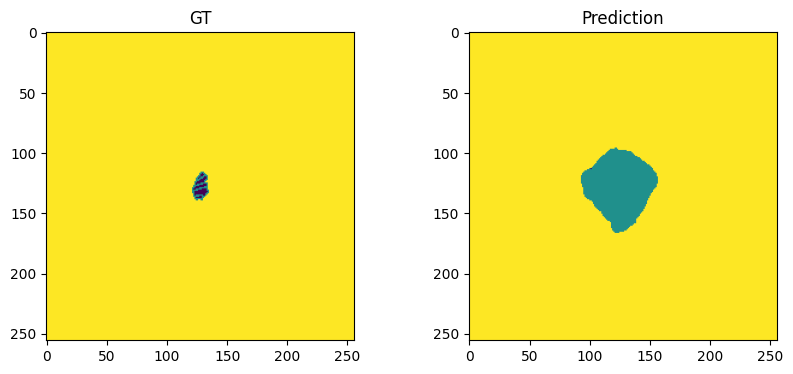

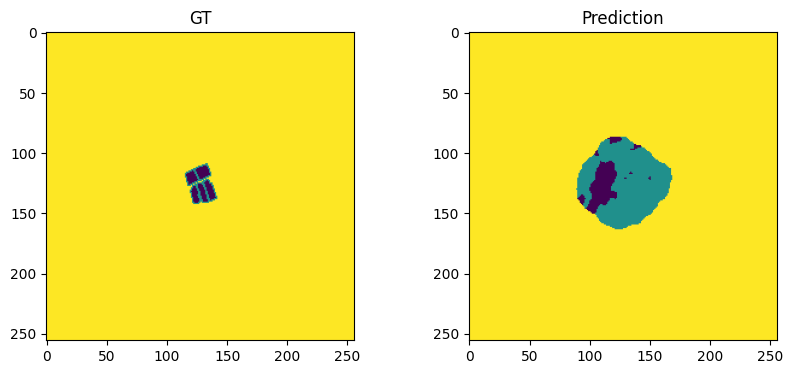

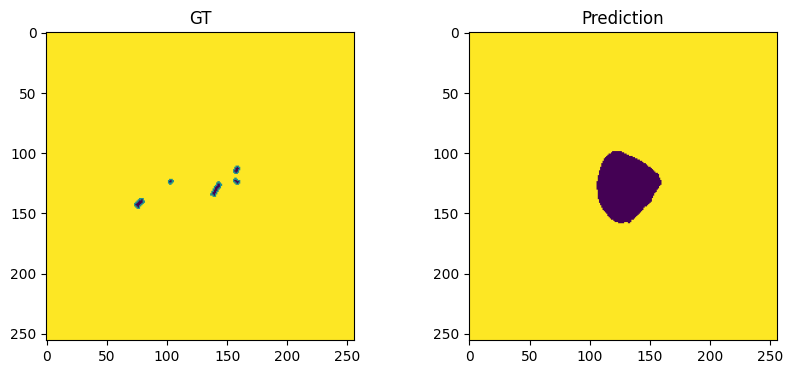

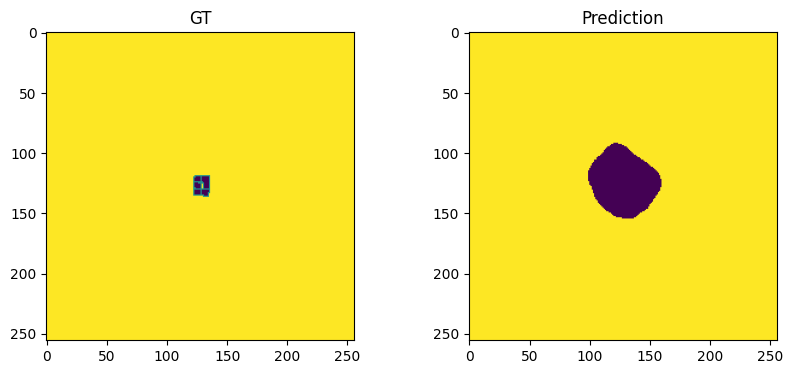

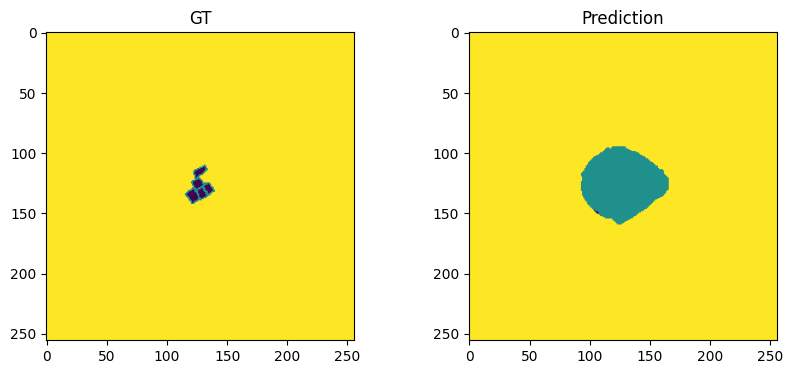

In [17]:
import random
import matplotlib.pyplot as plt

for _ in range(5):

    idx = random.randint(
        0,
        len(val_ds)-1
    )

    x,y = val_ds[idx]

    with torch.no_grad():

        pred = model(
            x.unsqueeze(0).to(device)
        )

    pred = pred.argmax(1).squeeze().cpu().numpy()

    gt = y.numpy()

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(gt)
    plt.title("GT")

    plt.subplot(1,2,2)
    plt.imshow(pred)
    plt.title("Prediction")

    plt.show()

In [18]:
import os
import numpy as np
import rasterio

fg_percentages = []

for f in os.listdir("semantic_3class"):

    m = rasterio.open(
        f"semantic_3class/{f}"
    ).read(1)

    fg = np.sum(
        (m == 1) | (m == 2)
    )

    fg_percentages.append(
        fg / m.size
    )

print(
    "Mean FG %",
    np.mean(fg_percentages) * 100
)

print(
    "Median FG %",
    np.median(fg_percentages) * 100
)

print(
    "Max FG %",
    np.max(fg_percentages) * 100
)

print(
    "Min FG %",
    np.min(fg_percentages) * 100
)

Mean FG % 0.9666468909982936
Median FG % 0.62103271484375
Max FG % 8.9569091796875
Min FG % 0.05035400390625
